In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df=pd.read_csv("../data/cleaned/ola_cleaned.csv")

print(df.shape)

df.head()

(100000, 36)


,Booking ID,Booking Date,Booking Time,City,Customer ID,Driver ID,Vehicle Type,Pickup Location,Drop Location,Booking Status,Ride Distance (km),Ride Duration (min),Booking Value,Surge Multiplier,Discount,Payment Method,Weather,Traffic,Driver Rating,Customer Rating,Cancelled by Customer Reason,Cancelled by Driver Reason,Weekend,Hour,Day,Month,Year,Weekday,Quarter,Peak Hour,Time Of Day,Fare Per KM,Booking Category,Distance Category,Driver Rating Category,Customer Rating Category
0,OLA000001,2024-03-25,16:38:00,Pune,C26989,D7632,Sedan,MG Road,Koramangala,Success,10.53,44,217.95,1.0,0,UPI,Rainy,High,4.5,4.0,NaN,NaN,No,16,25,March,2024,Monday,1,Normal,Afternoon,20.70,Low,Long,Excellent,Good
1,OLA000002,2024-04-01,14:52:00,Pune,C35331,D6588,Prime Sedan,Electronic City,Yelahanka,Success,11.63,38,266.08,1.0,40,Cash,Cloudy,High,4.6,5.1,NaN,NaN,No,14,1,April,2024,Monday,2,Normal,Afternoon,22.88,Low,Long,Excellent,Excellent
2,OLA000003,2024-09-11,01:18:00,Mumbai,C18767,D1455,Sedan,Whitefield,Electronic City,Success,2.06,8,90.90,1.0,60,UPI,Sunny,High,4.5,4.5,NaN,NaN,No,1,11,September,2024,Wednesday,3,Normal,Night,44.13,Low,Short,Excellent,Excellent
3,OLA000004,2024-06-28,23:38:00,Hyderabad,C21721,D1529,Prime SUV,Koramangala,Hebbal,Success,9.12,47,255.04,1.0,60,Card,Sunny,High,3.9,3.9,NaN,NaN,No,23,28,June,2024,Friday,2,Normal,Night,27.96,Low,Medium,Average,Average
4,OLA000005,2024-03-17,13:48:00,Hyderabad,C53922,D9618,Auto,Indiranagar,Whitefield,Success,2.74,18,66.99,1.0,0,UPI,Rainy,Low,4.7,6.1,NaN,NaN,Yes,13,17,March,2024,Sunday,1,Normal,Afternoon,24.45,Low,Short,Excellent,Excellent


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Booking ID                    100000 non-null  object 
 1   Booking Date                  100000 non-null  object 
 2   Booking Time                  100000 non-null  object 
 3   City                          100000 non-null  object 
 4   Customer ID                   100000 non-null  object 
 5   Driver ID                     100000 non-null  object 
 6   Vehicle Type                  100000 non-null  object 
 7   Pickup Location               100000 non-null  object 
 8   Drop Location                 100000 non-null  object 
 9   Booking Status                100000 non-null  object 
 10  Ride Distance (km)            100000 non-null  float64
 11  Ride Duration (min)           100000 non-null  int64  
 12  Booking Value                 100000 non-null

In [4]:
df.describe(include="all")

,Booking ID,Booking Date,Booking Time,City,Customer ID,Driver ID,Vehicle Type,Pickup Location,Drop Location,Booking Status,Ride Distance (km),Ride Duration (min),Booking Value,Surge Multiplier,Discount,Payment Method,Weather,Traffic,Driver Rating,Customer Rating,Cancelled by Customer Reason,Cancelled by Driver Reason,Weekend,Hour,Day,Month,Year,Weekday,Quarter,Peak Hour,Time Of Day,Fare Per KM,Booking Category,Distance Category,Driver Rating Category,Customer Rating Category
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000,100000,80139.000000,80139.000000,7938,6004,100000,100000.00000,100000.000000,100000,100000.0,100000,100000.000000,100000,100000,100000.000000,100000,100000,100000,100000
unique,100000,365,1440,6,60599,9000,6,10,10,5,NaN,NaN,NaN,NaN,NaN,4,4,3,NaN,NaN,4,4,2,NaN,NaN,12,NaN,7,NaN,3,4,NaN,4,4,5,5
top,OLA000001,2024-11-29,22:25:00,Chennai,C82381,D1810,Bike,MG Road,HSR Layout,Success,NaN,NaN,NaN,NaN,NaN,UPI,Sunny,Medium,NaN,NaN,Price too high,Shift ended,No,NaN,NaN,August,NaN,Friday,NaN,Normal,Night,NaN,Low,Medium,Excellent,Excellent
freq,1,316,96,16780,7,26,20180,10140,10118,80139,NaN,NaN,NaN,NaN,NaN,49979,55226,44873,NaN,NaN,2041,1579,71636,NaN,NaN,8593,NaN,14481,NaN,62673,33529,NaN,87671,36300,44097,36694
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.808472,47.894360,186.276670,1.046285,29.916200,NaN,NaN,NaN,4.499270,4.397725,NaN,NaN,NaN,11.51182,15.687140,NaN,2024.0,NaN,2.499750,NaN,NaN,25.293504,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.924771,35.842492,101.417529,0.144915,22.373332,NaN,NaN,NaN,0.401393,0.500744,NaN,NaN,NaN,6.93563,8.791153,NaN,0.0,NaN,1.117386,NaN,NaN,12.634296,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,3.000000,33.000000,1.000000,0.000000,NaN,NaN,NaN,2.800000,2.200000,NaN,NaN,NaN,0.00000,1.000000,NaN,2024.0,NaN,1.000000,NaN,NaN,13.410000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.420000,22.000000,114.300000,1.000000,0.000000,NaN,NaN,NaN,4.200000,4.100000,NaN,NaN,NaN,5.00000,8.000000,NaN,2024.0,NaN,1.000000,NaN,NaN,17.510000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.510000,39.000000,165.410000,1.000000,20.000000,NaN,NaN,NaN,4.500000,4.400000,NaN,NaN,NaN,12.00000,16.000000,NaN,2024.0,NaN,3.000000,NaN,NaN,21.780000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.770000,64.000000,236.000000,1.000000,40.000000,NaN,NaN,NaN,4.800000,4.700000,NaN,NaN,NaN,18.00000,23.000000,NaN,2024.0,NaN,3.000000,NaN,NaN,28.270000,NaN,NaN,NaN,NaN


In [5]:
total_rides=len(df)

total_revenue=df["Booking Value"].sum()

avg_fare=df["Booking Value"].mean()

avg_distance=df["Ride Distance (km)"].mean()

avg_driver=df["Driver Rating"].mean()

avg_customer=df["Customer Rating"].mean()

print("========== KPI ==========")

print("Total Rides :",total_rides)

print("Revenue :",round(total_revenue,2))

print("Average Fare :",round(avg_fare,2))

print("Average Distance :",round(avg_distance,2))

print("Average Driver Rating :",round(avg_driver,2))

print("Average Customer Rating :",round(avg_customer,2))

========== KPI ==========
Total Rides : 100000
Revenue : 18627666.96
Average Fare : 186.28
Average Distance : 8.81
Average Driver Rating : 4.5
Average Customer Rating : 4.4


In [6]:
status=df["Booking Status"].value_counts()

status

Booking Status
Success                  80139
Cancelled by Customer     7938
Cancelled by Driver       6004
Incomplete                2985
No Driver Found           2934
Name: count, dtype: int64

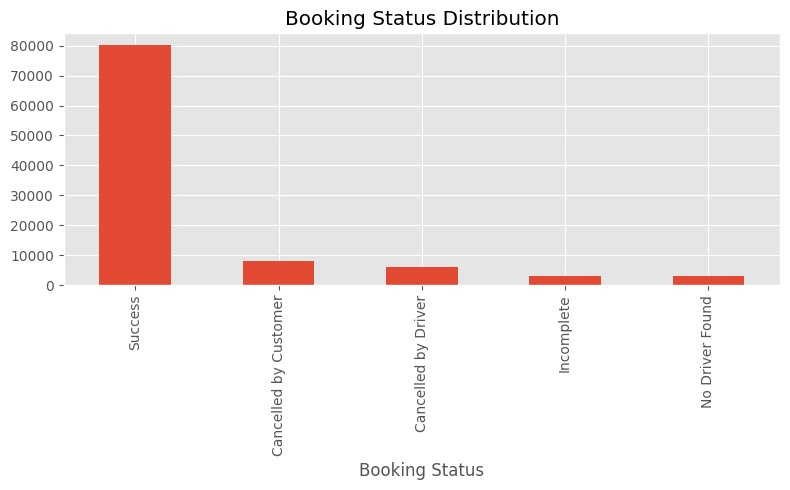

In [7]:
plt.figure(figsize=(8,5))

status.plot(kind="bar")

plt.title("Booking Status Distribution")

plt.tight_layout()

plt.show()

In [8]:
vehicle=df["Vehicle Type"].value_counts()

vehicle

Vehicle Type
Bike           20180
Sedan          18074
Auto           17797
Mini           17046
Prime Sedan    14967
Prime SUV      11936
Name: count, dtype: int64

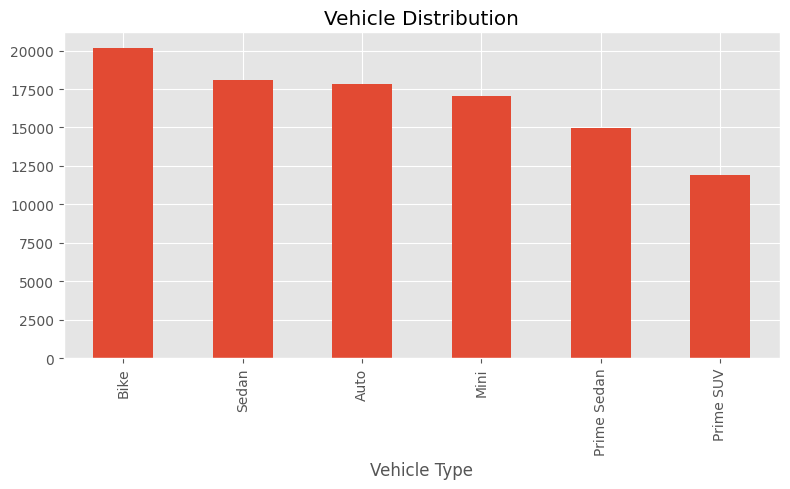

In [9]:
plt.figure(figsize=(8,5))

vehicle.plot(kind="bar")

plt.title("Vehicle Distribution")

plt.tight_layout()

plt.show()

In [10]:
vehicle_rev=df.groupby(

"Vehicle Type"

)["Booking Value"].sum().sort_values()

vehicle_rev

Vehicle Type
Auto           2743462.07
Bike           2818141.44
Mini           3006392.44
Prime SUV      3084818.95
Prime Sedan    3396870.80
Sedan          3577981.26
Name: Booking Value, dtype: float64

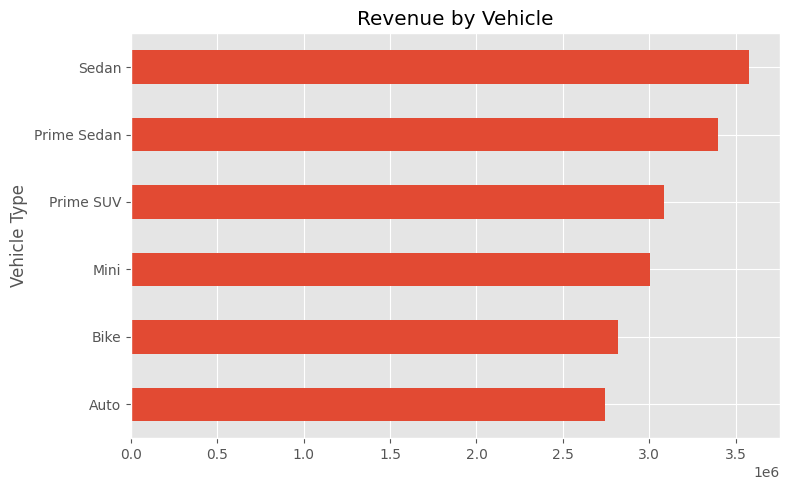

In [11]:
plt.figure(figsize=(8,5))

vehicle_rev.plot(kind="barh")

plt.title("Revenue by Vehicle")

plt.tight_layout()

plt.show()

In [12]:
avgfare=df.groupby(

"Vehicle Type"

)["Booking Value"].mean()

avgfare

Vehicle Type
Auto           154.153063
Bike           139.650220
Mini           176.369379
Prime SUV      258.446628
Prime Sedan    226.957360
Sedan          197.962889
Name: Booking Value, dtype: float64

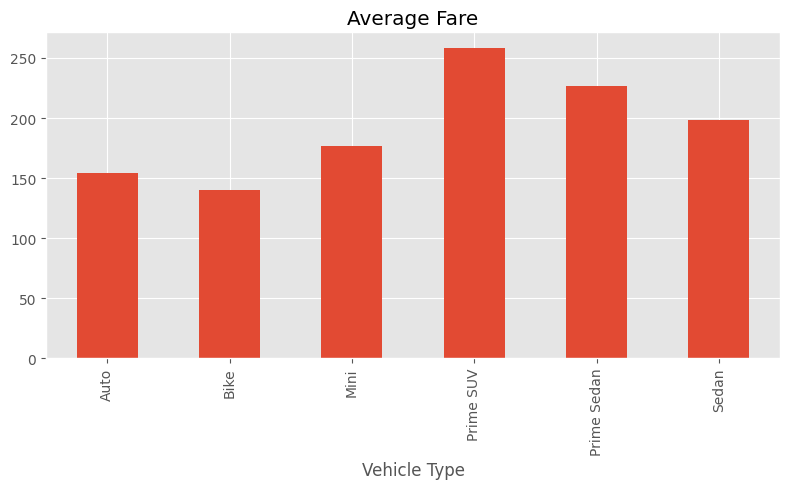

In [13]:
plt.figure(figsize=(8,5))

avgfare.plot(kind="bar")

plt.title("Average Fare")

plt.tight_layout()

plt.show()

In [14]:
distance=df.groupby(

"Vehicle Type"

)["Ride Distance (km)"].mean()

distance

Vehicle Type
Auto           8.779907
Bike           8.802597
Mini           8.829562
Prime SUV      8.909249
Prime Sedan    8.784428
Sedan          8.776627
Name: Ride Distance (km), dtype: float64

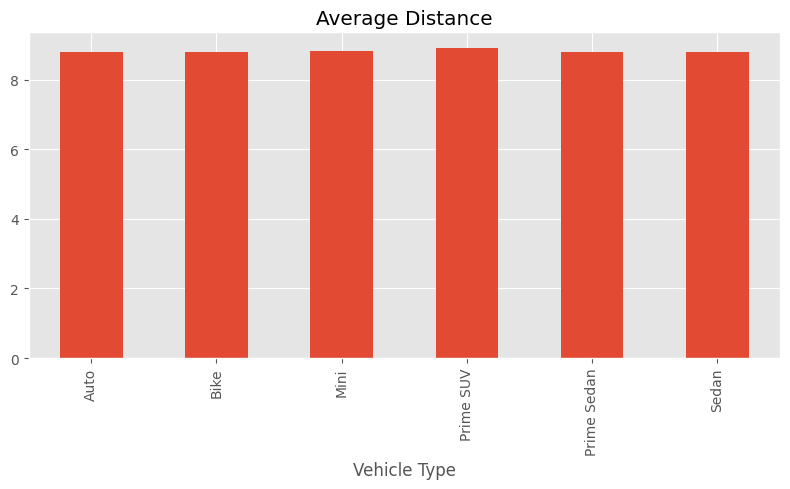

In [15]:
plt.figure(figsize=(8,5))

distance.plot(kind="bar")

plt.title("Average Distance")

plt.tight_layout()

plt.show()

In [16]:
city=df.groupby(

"City"

)["Booking Value"].sum().sort_values()

city

City
Delhi        3070336.76
Mumbai       3085263.91
Bengaluru    3097141.93
Pune         3108372.14
Hyderabad    3126540.19
Chennai      3140012.03
Name: Booking Value, dtype: float64

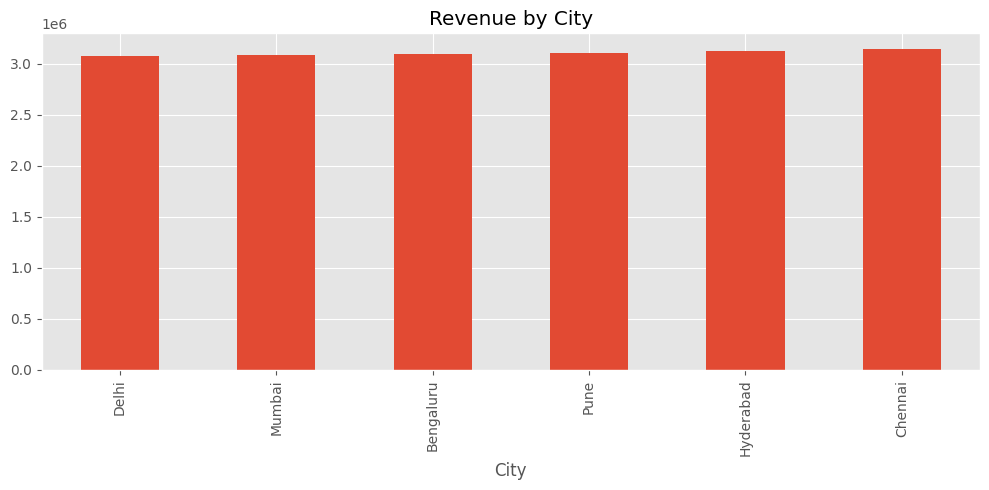

In [17]:
plt.figure(figsize=(10,5))

city.plot(kind="bar")

plt.title("Revenue by City")

plt.tight_layout()

plt.show()

In [18]:
rides=df["City"].value_counts()

rides

City
Chennai      16780
Hyderabad    16771
Pune         16648
Mumbai       16637
Delhi        16597
Bengaluru    16567
Name: count, dtype: int64

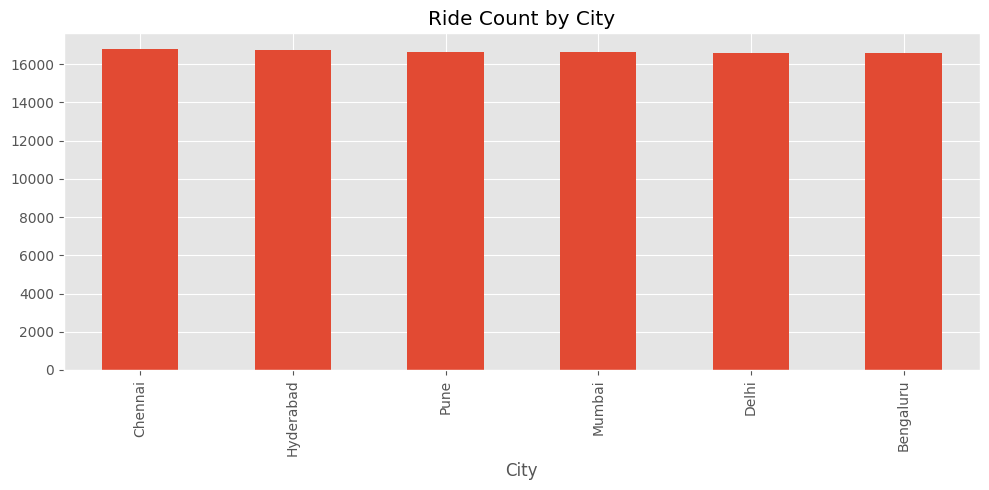

In [19]:
plt.figure(figsize=(10,5))

rides.plot(kind="bar")

plt.title("Ride Count by City")

plt.tight_layout()

plt.show()

In [20]:
payment=df["Payment Method"].value_counts()

payment

Payment Method
UPI       49979
Cash      19972
Card      19904
Wallet    10145
Name: count, dtype: int64

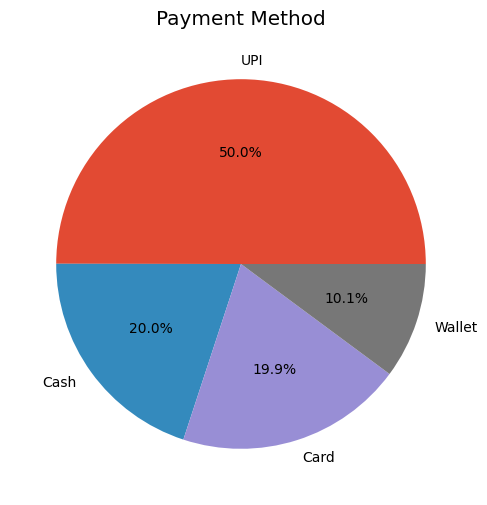

In [21]:
plt.figure(figsize=(8,6))

payment.plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Payment Method")

plt.show()

In [22]:
pay=df.groupby(

"Payment Method"

)["Booking Value"].sum()

pay

Payment Method
Card      3702102.58
Cash      3738764.50
UPI       9297054.57
Wallet    1889745.31
Name: Booking Value, dtype: float64

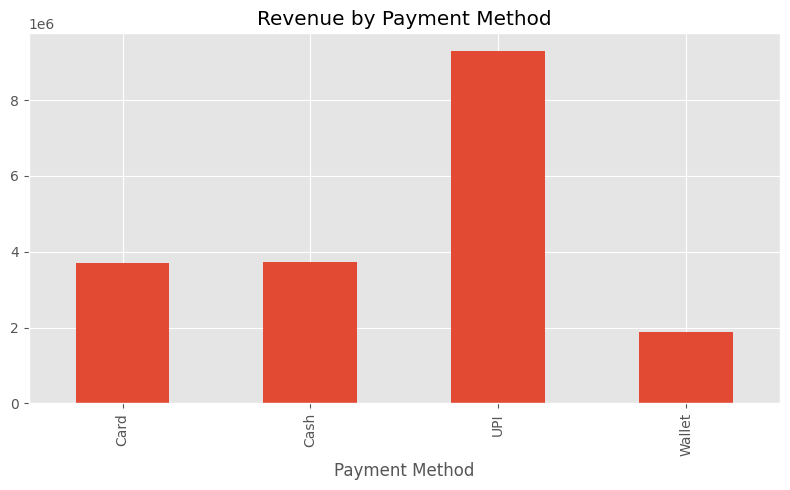

In [23]:
plt.figure(figsize=(8,5))

pay.plot(kind="bar")

plt.title("Revenue by Payment Method")

plt.tight_layout()

plt.show()

In [24]:
month=df["Month"].value_counts()

month

Month
August       8593
July         8574
May          8558
March        8510
January      8473
October      8407
December     8263
November     8224
June         8167
April        8128
September    8053
February     8050
Name: count, dtype: int64

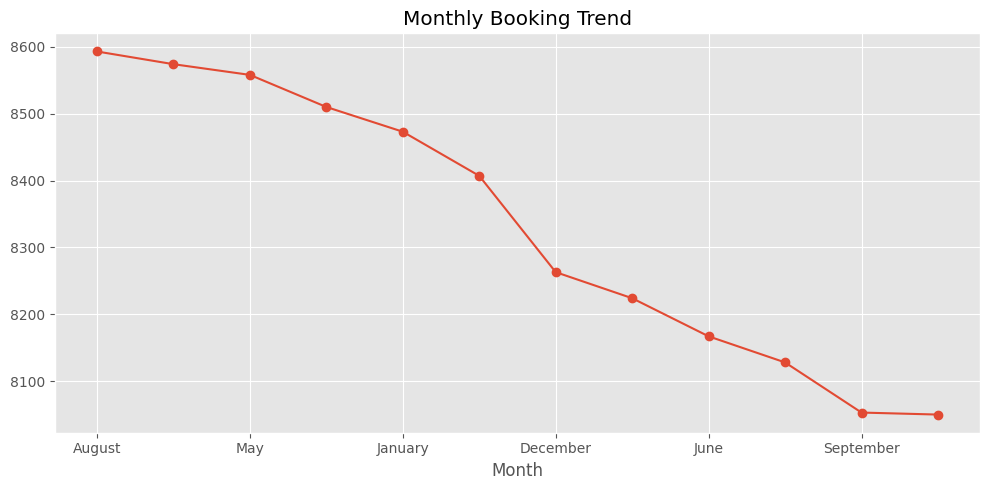

In [25]:
plt.figure(figsize=(10,5))

month.plot(kind="line",marker="o")

plt.title("Monthly Booking Trend")

plt.tight_layout()

plt.show()

In [26]:
weekday=df["Weekday"].value_counts()

weekday=weekday.reindex([

"Monday",

"Tuesday",

"Wednesday",

"Thursday",

"Friday",

"Saturday",

"Sunday"

])

weekday

Weekday
Monday       14284
Tuesday      14277
Wednesday    14312
Thursday     14282
Friday       14481
Saturday     14247
Sunday       14117
Name: count, dtype: int64

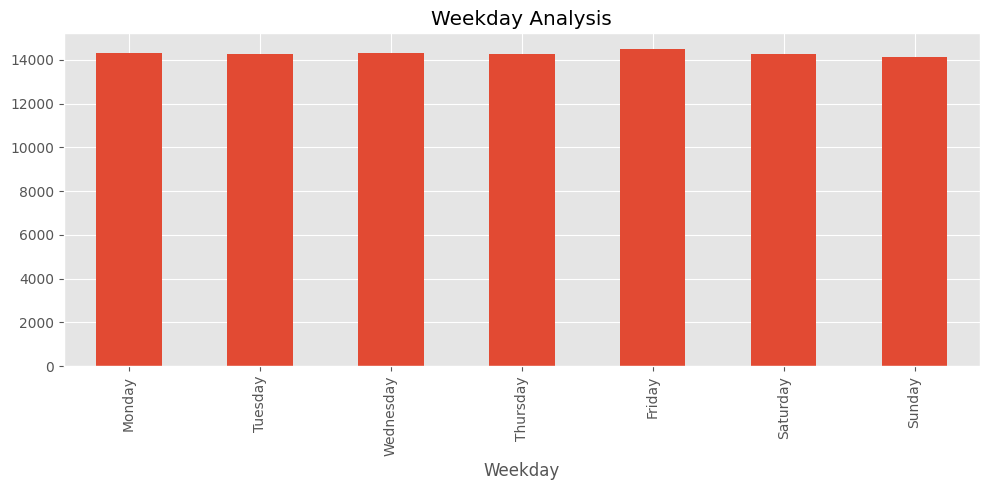

In [27]:
plt.figure(figsize=(10,5))

weekday.plot(kind="bar")

plt.title("Weekday Analysis")

plt.tight_layout()

plt.show()

In [28]:
hour=df["Hour"].value_counts().sort_index()

hour

Hour
0     4235
1     4195
2     4043
3     4246
4     4197
5     4167
6     4131
7     4211
8     4112
9     4065
10    4039
11    4163
12    4205
13    4197
14    4080
15    4189
16    4247
17    4191
18    4130
19    4193
20    4151
21    4235
22    4218
23    4160
Name: count, dtype: int64

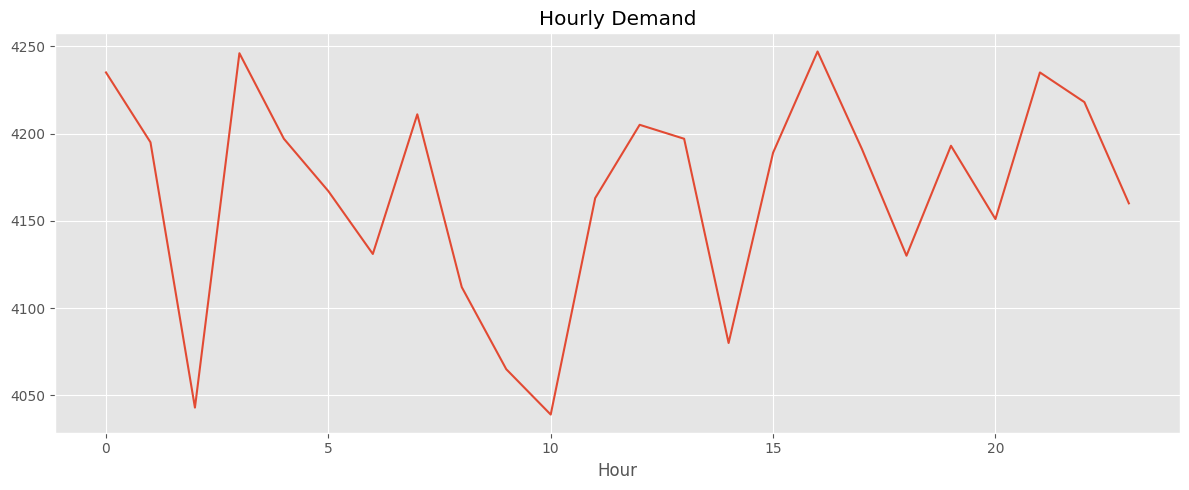

In [29]:
plt.figure(figsize=(12,5))

hour.plot(kind="line")

plt.title("Hourly Demand")

plt.tight_layout()

plt.show()

In [30]:
peak=df["Peak Hour"].value_counts()

peak

Peak Hour
Normal          62673
Evening Peak    20900
Morning Peak    16427
Name: count, dtype: int64

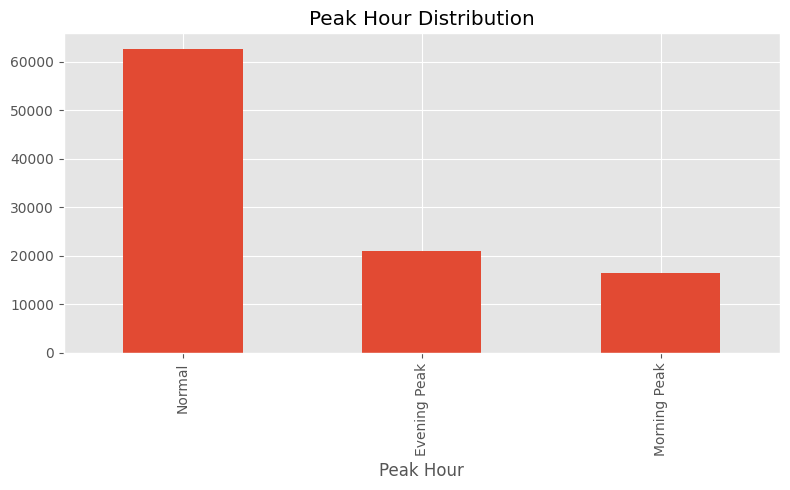

In [31]:
plt.figure(figsize=(8,5))

peak.plot(kind="bar")

plt.title("Peak Hour Distribution")

plt.tight_layout()

plt.show()

In [32]:
weekend=df["Weekend"].value_counts()

weekend

Weekend
No     71636
Yes    28364
Name: count, dtype: int64

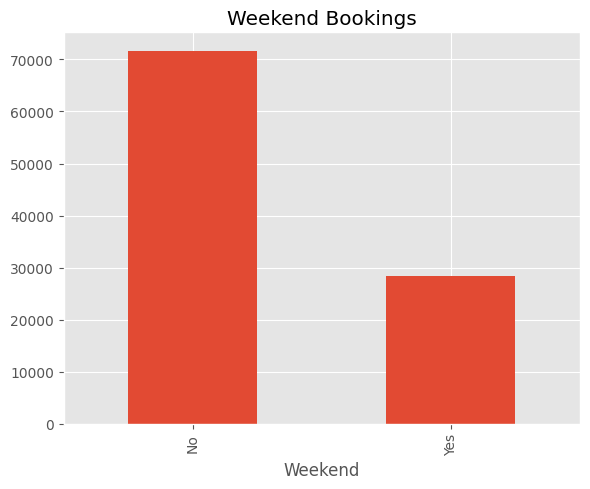

In [33]:
plt.figure(figsize=(6,5))

weekend.plot(kind="bar")

plt.title("Weekend Bookings")

plt.tight_layout()

plt.show()

In [34]:
booking=df["Booking Category"].value_counts()

booking

Booking Category
Low        87671
Medium     12206
High         122
Premium        1
Name: count, dtype: int64

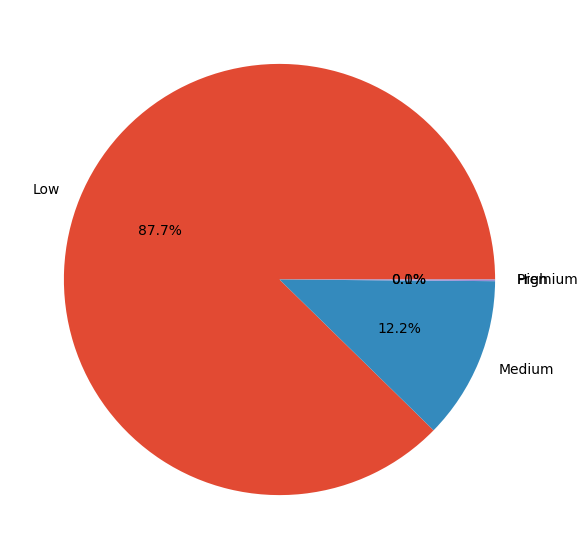

In [35]:
plt.figure(figsize=(7,7))

booking.plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.show()

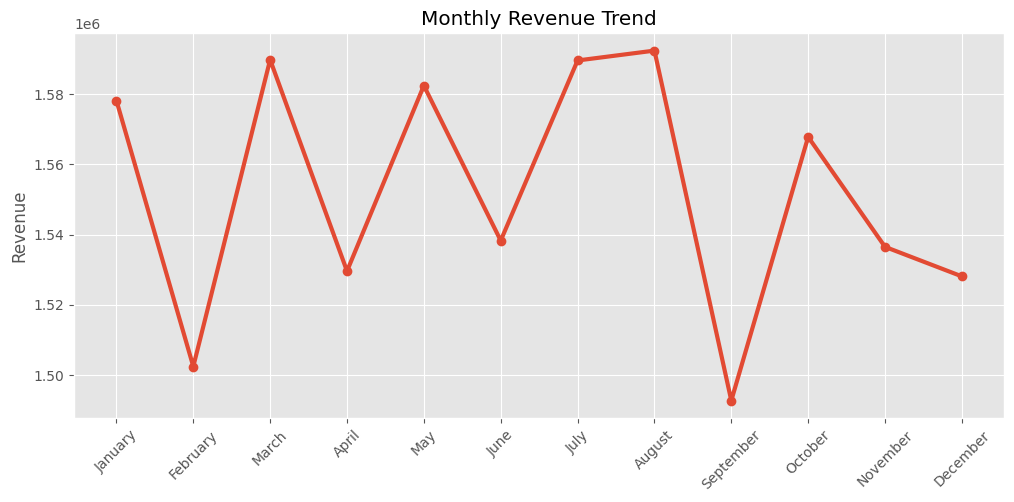

In [36]:
monthly_revenue = df.groupby("Month")["Booking Value"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_revenue = monthly_revenue.reindex(month_order)

plt.figure(figsize=(12,5))

plt.plot(monthly_revenue.index,
         monthly_revenue.values,
         marker="o",
         linewidth=3)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

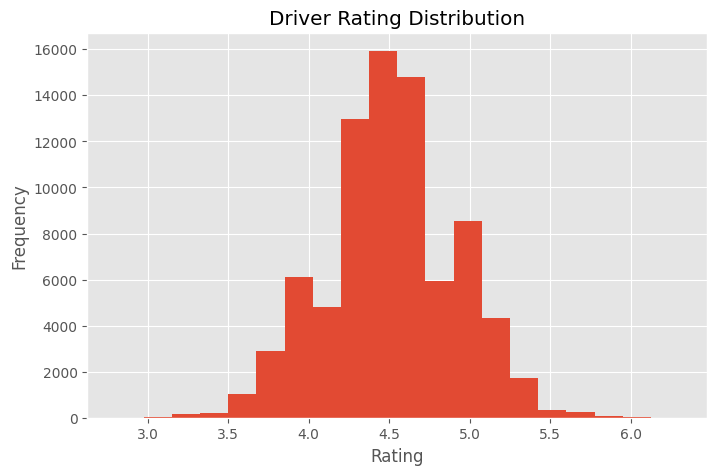

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Driver Rating"].dropna(),
    bins=20
)

plt.title("Driver Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

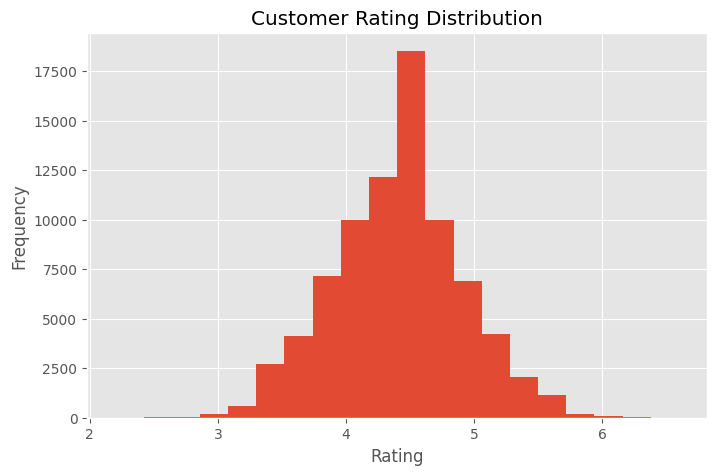

In [38]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Customer Rating"].dropna(),
    bins=20
)

plt.title("Customer Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

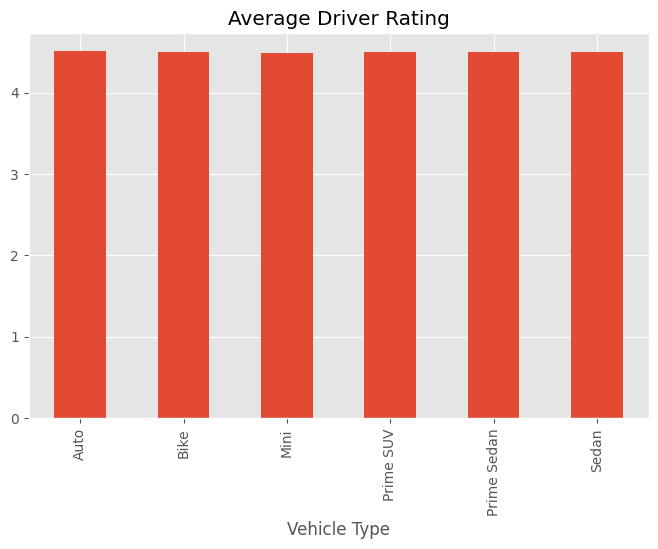

In [39]:
rating=df.groupby(

"Vehicle Type"

)["Driver Rating"].mean()

plt.figure(figsize=(8,5))

rating.plot(kind="bar")

plt.title("Average Driver Rating")

plt.show()

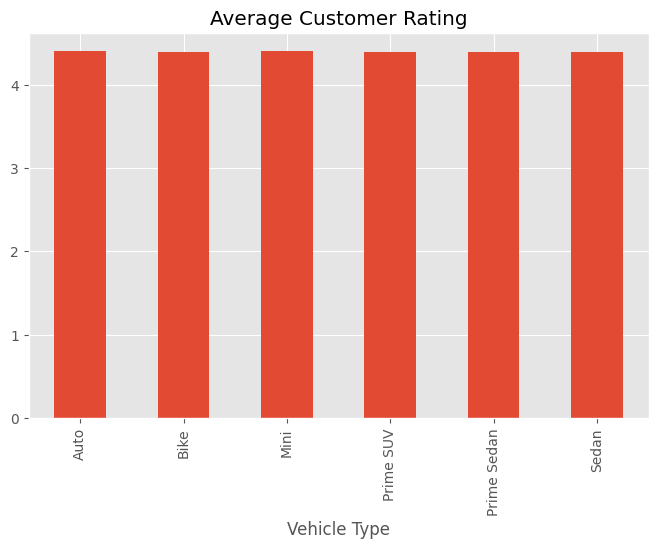

In [40]:
rating=df.groupby(

"Vehicle Type"

)["Customer Rating"].mean()

plt.figure(figsize=(8,5))

rating.plot(kind="bar")

plt.title("Average Customer Rating")

plt.show()

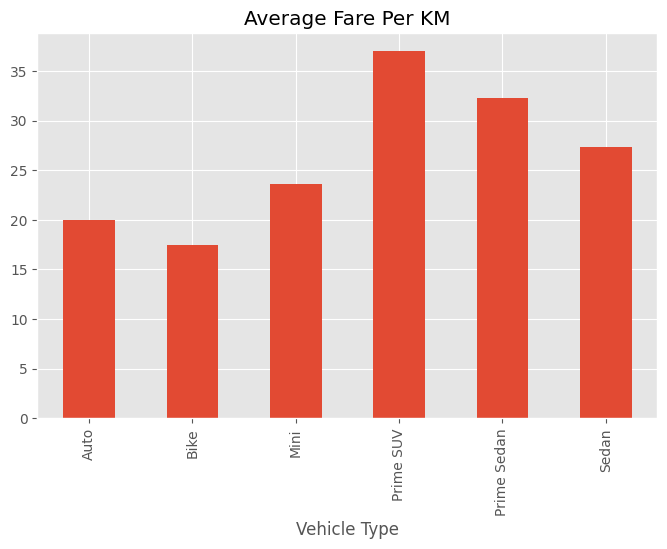

In [41]:
fare=df.groupby(

"Vehicle Type"

)["Fare Per KM"].mean()

plt.figure(figsize=(8,5))

fare.plot(kind="bar")

plt.title("Average Fare Per KM")

plt.show()

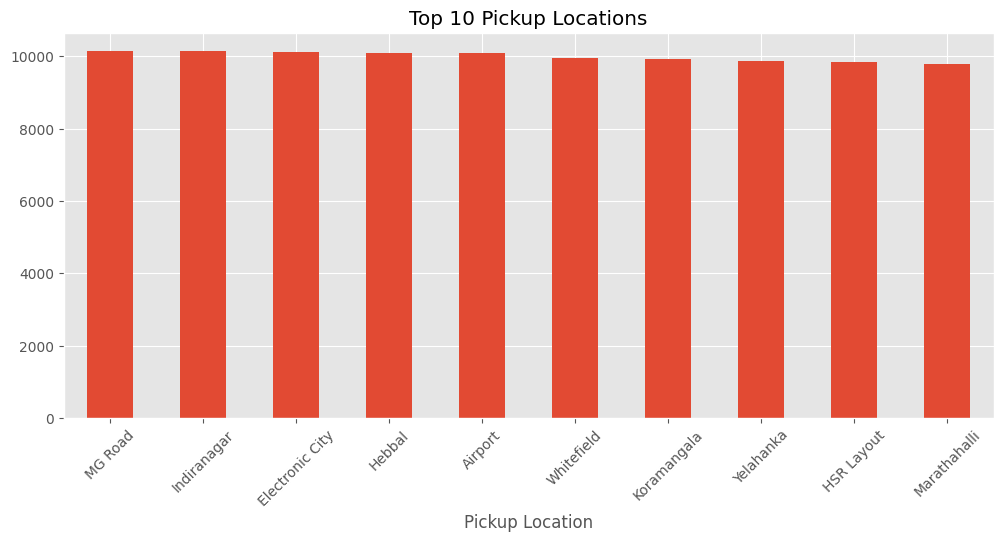

In [42]:
pickup=df["Pickup Location"].value_counts().head(10)

plt.figure(figsize=(12,5))

pickup.plot(kind="bar")

plt.title("Top 10 Pickup Locations")

plt.xticks(rotation=45)

plt.show()

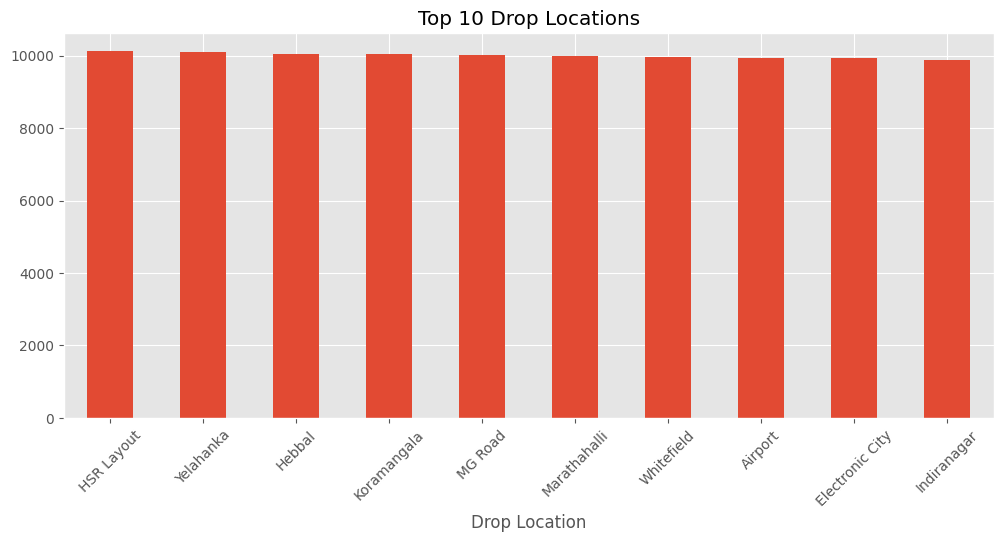

In [43]:
drop=df["Drop Location"].value_counts().head(10)

plt.figure(figsize=(12,5))

drop.plot(kind="bar")

plt.title("Top 10 Drop Locations")

plt.xticks(rotation=45)

plt.show()

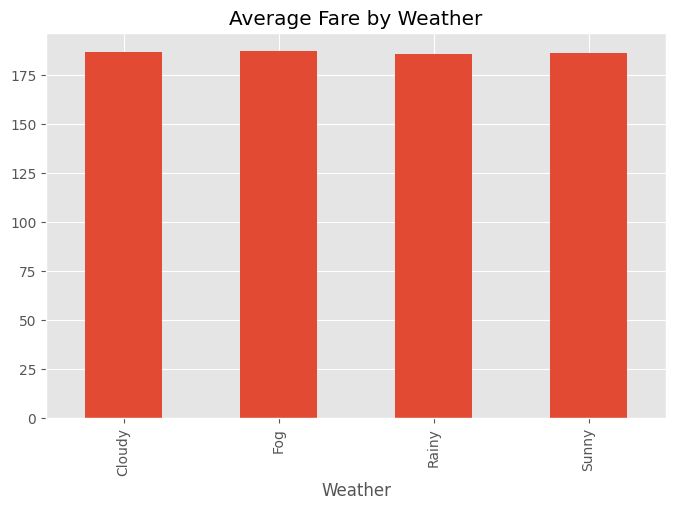

In [44]:
weather=df.groupby(

"Weather"

)["Booking Value"].mean()

plt.figure(figsize=(8,5))

weather.plot(kind="bar")

plt.title("Average Fare by Weather")

plt.show()

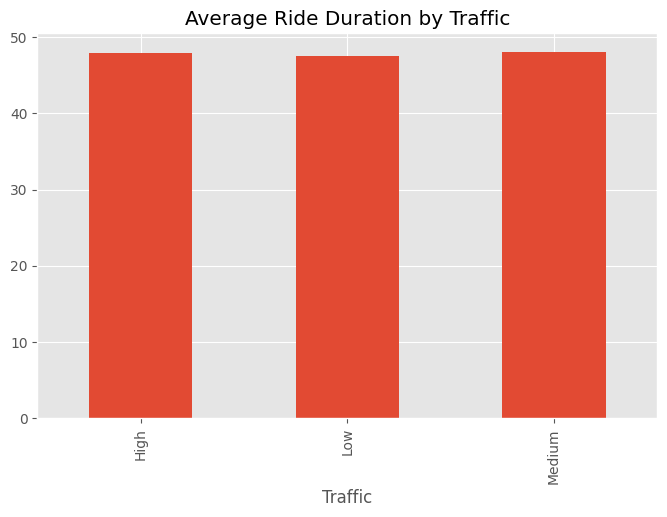

In [45]:
traffic=df.groupby(

"Traffic"

)["Ride Duration (min)"].mean()

plt.figure(figsize=(8,5))

traffic.plot(kind="bar")

plt.title("Average Ride Duration by Traffic")

plt.show()

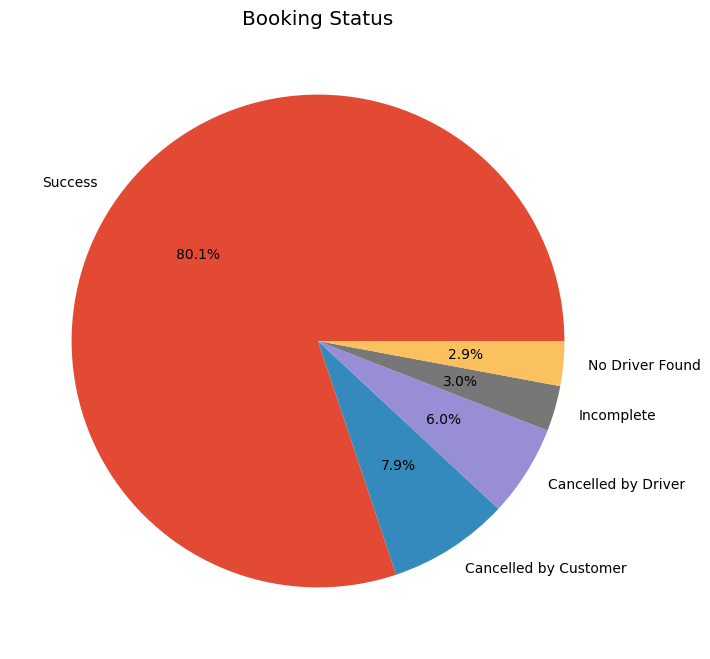

In [46]:
status=df["Booking Status"].value_counts()

plt.figure(figsize=(8,8))

status.plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Booking Status")

plt.show()

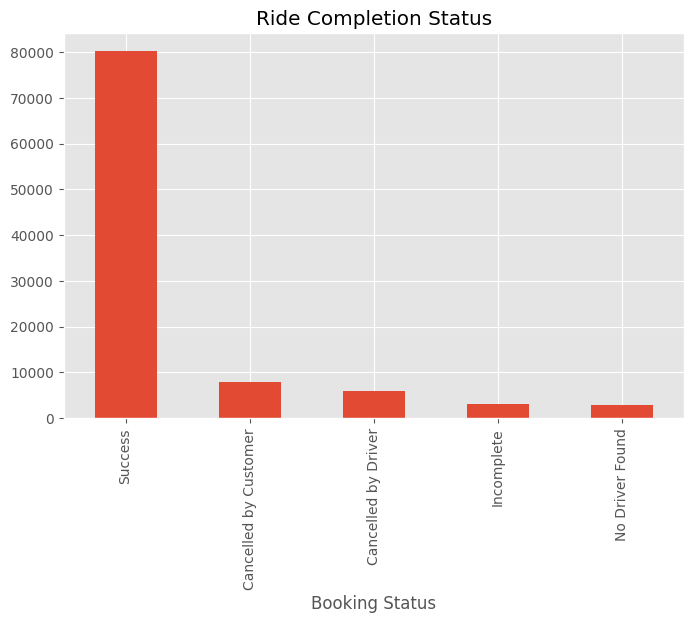

In [47]:
status=df["Booking Status"].value_counts()

plt.figure(figsize=(8,5))

status.plot(kind="bar")

plt.title("Ride Completion Status")

plt.show()

In [48]:
city=df.groupby(

"City"

)["Booking Value"].sum().reset_index()

fig=px.bar(

city,

x="City",

y="Booking Value",

title="Revenue by City"

)

fig.show()

In [49]:
vehicle=df.groupby(

"Vehicle Type"

)["Booking Value"].sum().reset_index()

fig=px.pie(

vehicle,

values="Booking Value",

names="Vehicle Type",

title="Revenue Share"

)

fig.show()

In [50]:
hour=df.groupby(

"Hour"

)["Booking ID"].count().reset_index()

fig=px.line(

hour,

x="Hour",

y="Booking ID",

markers=True,

title="Hourly Booking Trend"

)

fig.show()

In [51]:
numeric=df.select_dtypes(include=np.number)

corr=numeric.corr()

corr

,Ride Distance (km),Ride Duration (min),Booking Value,Surge Multiplier,Discount,Driver Rating,Customer Rating,Hour,Day,Year,Quarter,Fare Per KM
Ride Distance (km),1.000000,0.904830,0.893023,-0.001324,-0.001336,-0.004861,-0.001000,-0.001234,-0.000548,NaN,-0.002349,-0.487888
Ride Duration (min),0.904830,1.000000,0.806288,-0.004202,-0.001675,-0.005349,-0.000229,-0.002463,-0.000272,NaN,-0.001538,-0.443195
Booking Value,0.893023,0.806288,1.000000,0.182258,-0.001609,-0.003645,-0.000353,0.026238,-0.000036,NaN,-0.003544,-0.227363
Surge Multiplier,-0.001324,-0.004202,0.182258,1.000000,0.005160,0.001203,0.002026,0.150602,0.001268,NaN,-0.004205,0.170520
Discount,-0.001336,-0.001675,-0.001609,0.005160,1.000000,-0.006403,0.002883,0.001506,0.004653,NaN,-0.001881,-0.001350
Driver Rating,-0.004861,-0.005349,-0.003645,0.001203,-0.006403,1.000000,0.000352,0.003498,-0.002209,NaN,-0.003510,0.003260
Customer Rating,-0.001000,-0.000229,-0.000353,0.002026,0.002883,0.000352,1.000000,-0.003860,0.001311,NaN,0.005414,0.000343
Hour,-0.001234,-0.002463,0.026238,0.150602,0.001506,0.003498,-0.003860,1.000000,-0.000008,NaN,0.001605,0.025471
Day,-0.000548,-0.000272,-0.000036,0.001268,0.004653,-0.002209,0.001311,-0.000008,1.000000,NaN,-0.001328,-0.001213
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
fig=px.imshow(

corr,

text_auto=True,

aspect="auto",

title="Correlation Matrix"

)

fig.show()

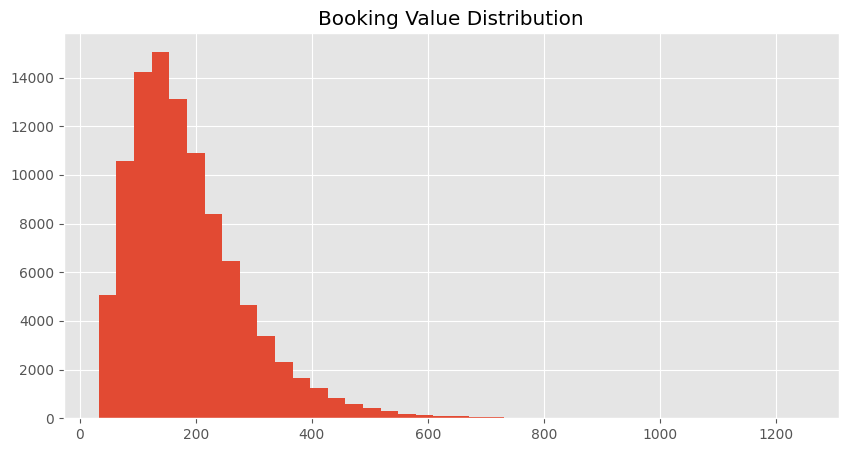

In [53]:
plt.figure(figsize=(10,5))

plt.hist(

df["Booking Value"],

bins=40

)

plt.title("Booking Value Distribution")

plt.show()

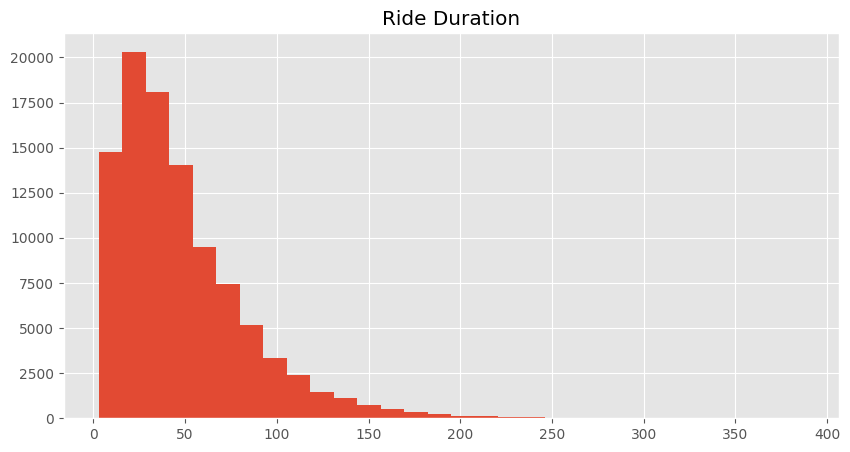

In [54]:
plt.figure(figsize=(10,5))

plt.hist(

df["Ride Duration (min)"],

bins=30

)

plt.title("Ride Duration")

plt.show()

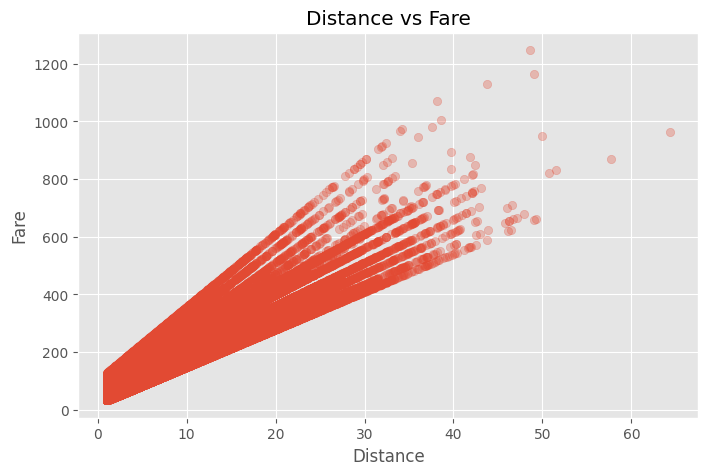

In [55]:
plt.figure(figsize=(8,5))

plt.scatter(

df["Ride Distance (km)"],

df["Booking Value"],

alpha=0.3

)

plt.xlabel("Distance")

plt.ylabel("Fare")

plt.title("Distance vs Fare")

plt.show()

In [56]:
top=df.groupby(

"City"

)["Booking Value"].sum().sort_values(ascending=False)

top

City
Chennai      3140012.03
Hyderabad    3126540.19
Pune         3108372.14
Bengaluru    3097141.93
Mumbai       3085263.91
Delhi        3070336.76
Name: Booking Value, dtype: float64

In [57]:
top=df.groupby(

"Vehicle Type"

)["Booking Value"].sum().sort_values(ascending=False)

top

Vehicle Type
Sedan          3577981.26
Prime Sedan    3396870.80
Prime SUV      3084818.95
Mini           3006392.44
Bike           2818141.44
Auto           2743462.07
Name: Booking Value, dtype: float64

In [58]:
kpi=pd.DataFrame({

"KPI":[

"Total Rides",

"Revenue",

"Average Fare",

"Average Distance",

"Driver Rating",

"Customer Rating"

],

"Value":[

len(df),

df["Booking Value"].sum(),

round(df["Booking Value"].mean(),2),

round(df["Ride Distance (km)"].mean(),2),

round(df["Driver Rating"].mean(),2),

round(df["Customer Rating"].mean(),2)

]

})

kpi

,KPI,Value
0,Total Rides,100000.00
1,Revenue,18627666.96
2,Average Fare,186.28
3,Average Distance,8.81
4,Driver Rating,4.50
5,Customer Rating,4.40


In [59]:
kpi.to_csv(

"../reports/eda_summary.csv",

index=False

)

print("EDA Report Saved Successfully")

EDA Report Saved Successfully
